# Lensed Supernovae Population with Multi-Survey Variability
This notebook simulates a lensed SN Ia population using `slsim`, showcasing dynamic 
time-lapse rendering and microlensing extraction across LSST, Roman, and Euclid observatories.

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity

# from astropy.table import Table, vstack

import speclite.filters
import slsim
import slsim.Pipelines as pipelines
import slsim.Deflectors as deflectors
from slsim.Sources.SourcePopulation.point_plus_extended_sources import (
    PointPlusExtendedSources,
)
from slsim.Sources.SourceCatalogues.SupernovaeCatalog import SupernovaeCatalog
from slsim.Lenses.lens_pop import LensPop
from slsim.ImageSimulation.image_simulation import simulate_image
from slsim.Util.astro_util import theta_star_physical

from slsim.Pipelines import roman_speclite
from slsim.ImageSimulation.image_quality_lenstronomy import (
    ROMAN_BAND_LIST,
    LSST_BAND_LIST,
    # EUCLID_BAND_LIST,
)

%load_ext autoreload
%autoreload 2

## 1. Filter Setup

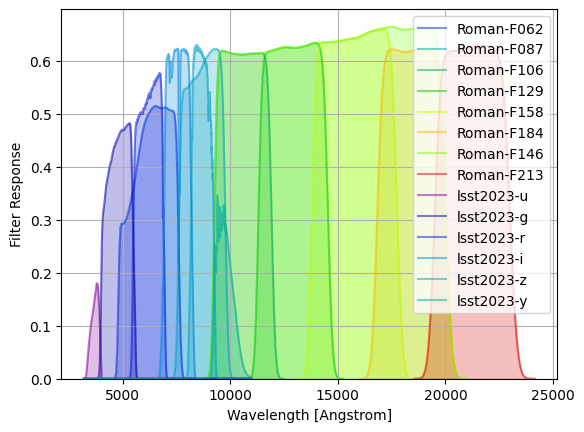

In [2]:
# %%
roman_speclite.configure_roman_filters()

filters = speclite.filters.load_filters(
    # "Euclid-VIS",
    "Roman-F062",
    "Roman-F087",
    "Roman-F106",
    "Roman-F129",
    "Roman-F158",
    "Roman-F184",
    "Roman-F146",
    "Roman-F213",
    "lsst2023-u",
    "lsst2023-g",
    "lsst2023-r",
    "lsst2023-i",
    "lsst2023-z",
    "lsst2023-y",
)

speclite.filters.plot_filters(filters)

## 2. SNe Population Generation

In [ ]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
sky_area = Quantity(value=1, unit="deg2")

path = os.path.dirname(slsim.__file__)
skypy_config_path = os.path.join(
    os.path.split(path)[0], "data/SkyPy/roman-lsst-like.yml"
)

galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=skypy_config_path,
    sky_area=sky_area,
    filters=None,
    cosmo=cosmo,
    z_min=0.0,
    z_max=5.0,
)

lens_galaxies = deflectors.AllLensGalaxies(
    red_galaxy_list=galaxy_simulation_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_simulation_pipeline.blue_galaxies,
    kwargs_cut={"band": "i", "band_max": 28, "z_min": 0.01, "z_max": 2.5},
    kwargs_mass2light={},
    cosmo=cosmo,
    sky_area=sky_area,
)

sn_time_range = np.linspace(-100, 300, 500)
all_sn_bands = LSST_BAND_LIST + ROMAN_BAND_LIST  # + EUCLID_BAND_LIST


supernovae_catalog = SupernovaeCatalog(
    sn_type="Ia",
    band_list=all_sn_bands,
    lightcurve_time=sn_time_range,
    absolute_mag_band="bessellb",
    absolute_mag=None,
    mag_zpsys="ab",
    cosmo=cosmo,
    skypy_config=skypy_config_path,
    sky_area=sky_area,
    host_galaxy_candidate=galaxy_simulation_pipeline.blue_galaxies,
)
supernovae_data = supernovae_catalog.supernovae_catalog(
    host_galaxy=True, lightcurve=True
)

# This file can be downloaded from here: https://github.com/LSST-strong-lensing/data_public .
# Please download this file and replace the path with your path.
sn_modeldir = "SALT3.NIR_WAVEEXT"

supernovae_host_population = PointPlusExtendedSources(
    point_plus_extended_sources_list=supernovae_data,
    cosmo=cosmo,
    sky_area=sky_area,
    kwargs_cut={"z_min": 0.1, "z_max": 5.0},
    list_type="astropy_table",
    catalog_type="skypy",
    point_source_type="supernova",
    extended_source_type="single_sersic",
    point_source_kwargs={
        "variability_model": "light_curve",
        "kwargs_variability": ["supernovae_lightcurve"] + all_sn_bands,
        "sn_type": "Ia",
        "sn_absolute_mag_band": "bessellb",
        "sn_absolute_zpsys": "ab",
        "lightcurve_time": sn_time_range,
        "sn_modeldir": sn_modeldir,
    },
)

## 3. Lens Selection & Time-Lapse Visualization
We render the Supernova exploding and fading across the lensing system.

In [4]:
supernova_lens_pop = LensPop(
    deflector_population=lens_galaxies,
    source_population=supernovae_host_population,
    sky_area=sky_area * 1000,
    cosmo=cosmo,
)

kwargs_lens_cut = {
    "min_image_separation": 0.5,
    "max_image_separation": 10.0,
    # "second_brightest_image_cut": {"i": 25.0}
}
selected_lenses = supernova_lens_pop.draw_population(
    kwargs_lens_cuts=kwargs_lens_cut, speed_factor=10000
)

In [5]:
# select lens_class based on the peak magnitude
lens_class = None
# best_selected_lenses = []
for lens in selected_lenses:
    ps_mags = lens.point_source_magnitude(band="i", time=np.linspace(-100, 300, 500))[0]
    peak_mag = np.min(ps_mags)
    if peak_mag < 24.0:  # Example threshold for brightness
        print(
            f"Selected lens with peak magnitude {peak_mag:.2f} and Einstein radius {lens.einstein_radius[0]:.2f} arcsec"
        )
        lens_class = lens
        break

/global/homes/s/sharma/.venv/lib/python3.13/site-packages/sncosmo/models.py:189: RuntimeWarning: divide by zero encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
/global/homes/s/sharma/.venv/lib/python3.13/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


Selected lens with peak magnitude 23.35 and Einstein radius 0.65 arcsec


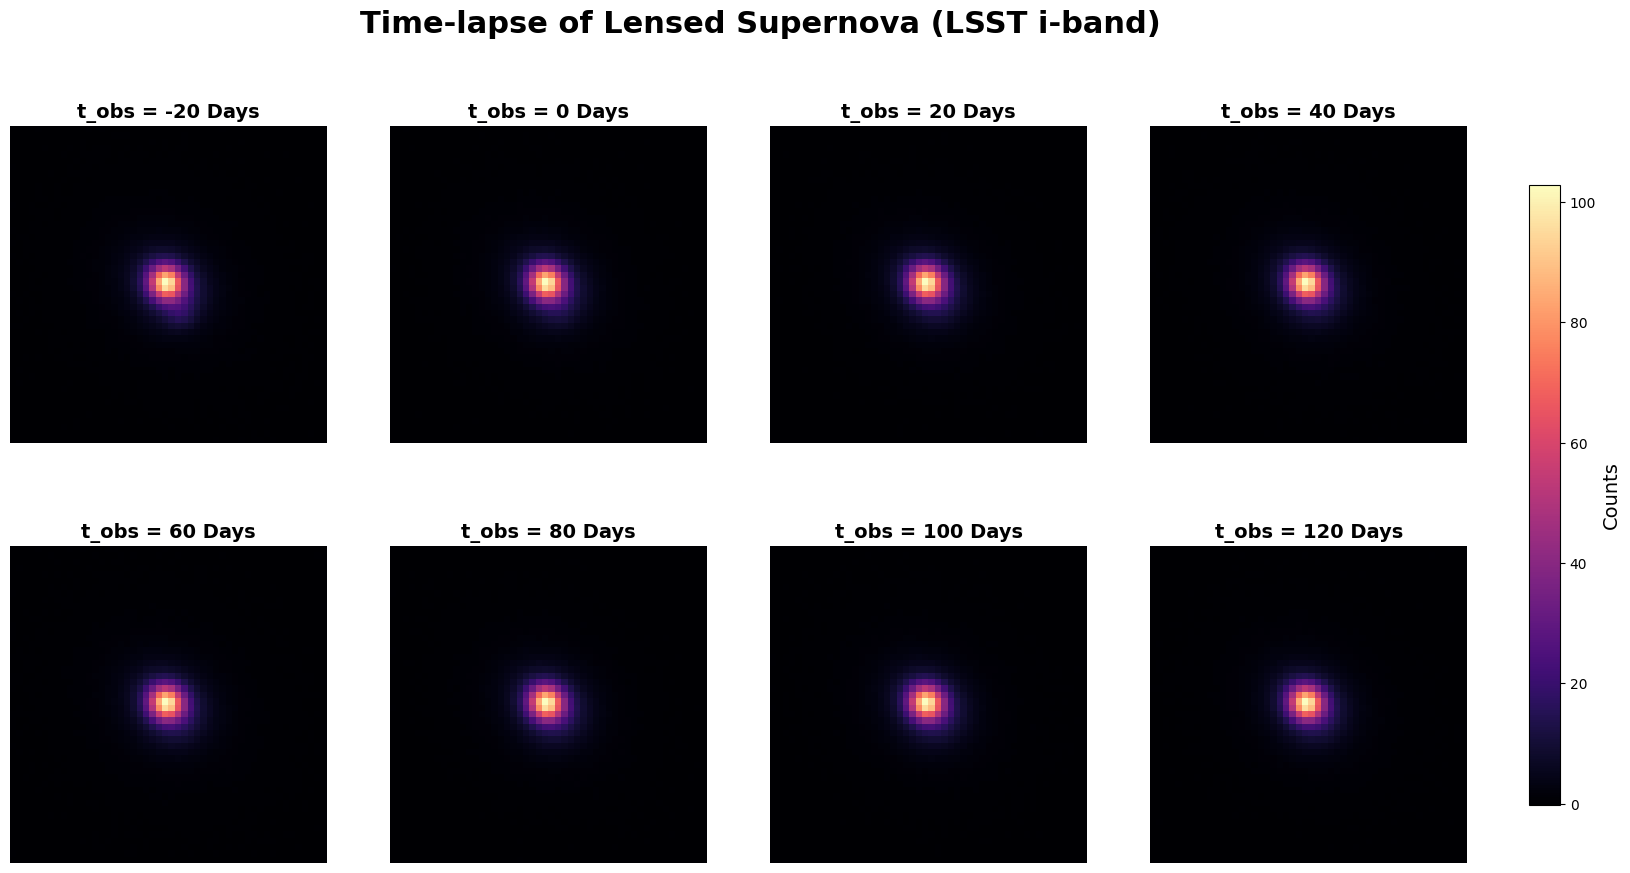

In [6]:
observation_times = [-20, 0, 20, 40, 60, 80, 100, 120]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

band = "i"  # LSST i-band
for idx, t in enumerate(observation_times):
    img = simulate_image(
        lens_class,
        band=band,
        num_pix=50,
        add_noise=True,
        add_background_counts=False,
        observatory="LSST",
        with_source=True,
        with_deflector=True,
        with_point_source=True,
        t_obs=t,
    )
    im = axes[idx].imshow(img, origin="lower", cmap="magma")
    axes[idx].set_title(f"t_obs = {t} Days", fontsize=14, fontweight="bold")
    axes[idx].axis("off")

cbar = fig.colorbar(
    im, ax=axes.ravel().tolist(), orientation="vertical", fraction=0.02, pad=0.04
)
cbar.set_label("Counts", fontsize=14)
plt.suptitle(
    f"Time-lapse of Lensed Supernova (LSST {band}-band)", fontsize=22, fontweight="bold"
)
plt.show()

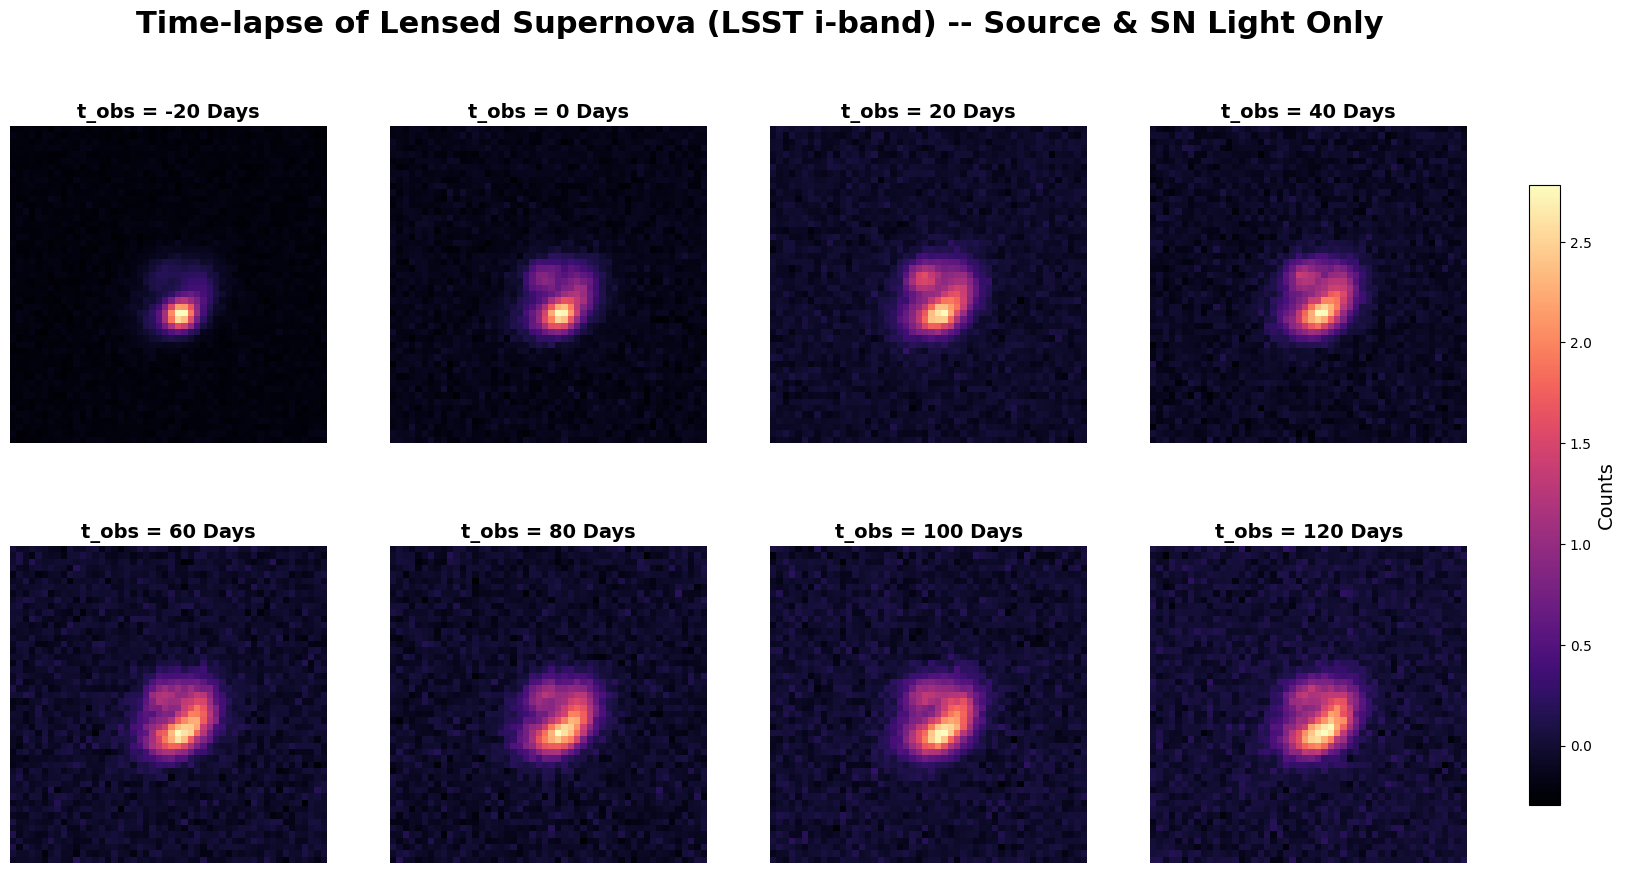

In [7]:
observation_times = [-20, 0, 20, 40, 60, 80, 100, 120]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

band = "i"  # LSST i-band
for idx, t in enumerate(observation_times):
    img = simulate_image(
        lens_class,
        band=band,
        num_pix=50,
        add_noise=True,
        add_background_counts=False,
        observatory="LSST",
        with_source=True,
        with_deflector=False,
        with_point_source=True,
        t_obs=t,
    )
    im = axes[idx].imshow(img, origin="lower", cmap="magma")
    axes[idx].set_title(f"t_obs = {t} Days", fontsize=14, fontweight="bold")
    axes[idx].axis("off")

cbar = fig.colorbar(
    im, ax=axes.ravel().tolist(), orientation="vertical", fraction=0.02, pad=0.04
)
cbar.set_label("Counts", fontsize=14)
plt.suptitle(
    f"Time-lapse of Lensed Supernova (LSST {band}-band) -- Source & SN Light Only",
    fontsize=22,
    fontweight="bold",
)
plt.show()

In [ ]:
with open("lens_sne_Ia.pkl", "wb") as f:
    pickle.dump(lens_class, f)
print(
    f"Lens pickled — deflector z={lens_class.deflector_redshift:.4f}, "
    f"source z={lens_class.source_redshift_list[0]:.4f}"
)

Lens pickled — deflector z=0.3785, source z=0.7626


## 4. Visualize Lightcurves with Microlensing Effects
We map the time-varying Supernova expansion grids through the magnification map to extract continuous residuals for LSST and Roman.

Processing Multi-Band SNe Macrolensing and Microlensing...
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
Visualizing Continuous SNe Macrolensing + Microlensing Signatures...


/tmp/ipykernel_500947/405337620.py:70: RuntimeWarning: invalid value encountered in subtract
  ax_lsst_ml.plot(t_test, lsst_micro[band][i] - lsst_macro[band][i], color=c, lw=2.5, alpha=0.8, label=f"ML Only ({band})")
/tmp/ipykernel_500947/405337620.py:83: RuntimeWarning: invalid value encountered in subtract
  ax_roman_ml.plot(t_test, roman_micro[band][i] - roman_macro[band][i], color=c, lw=2.5, alpha=0.8, label=f"ML Only ({band})")


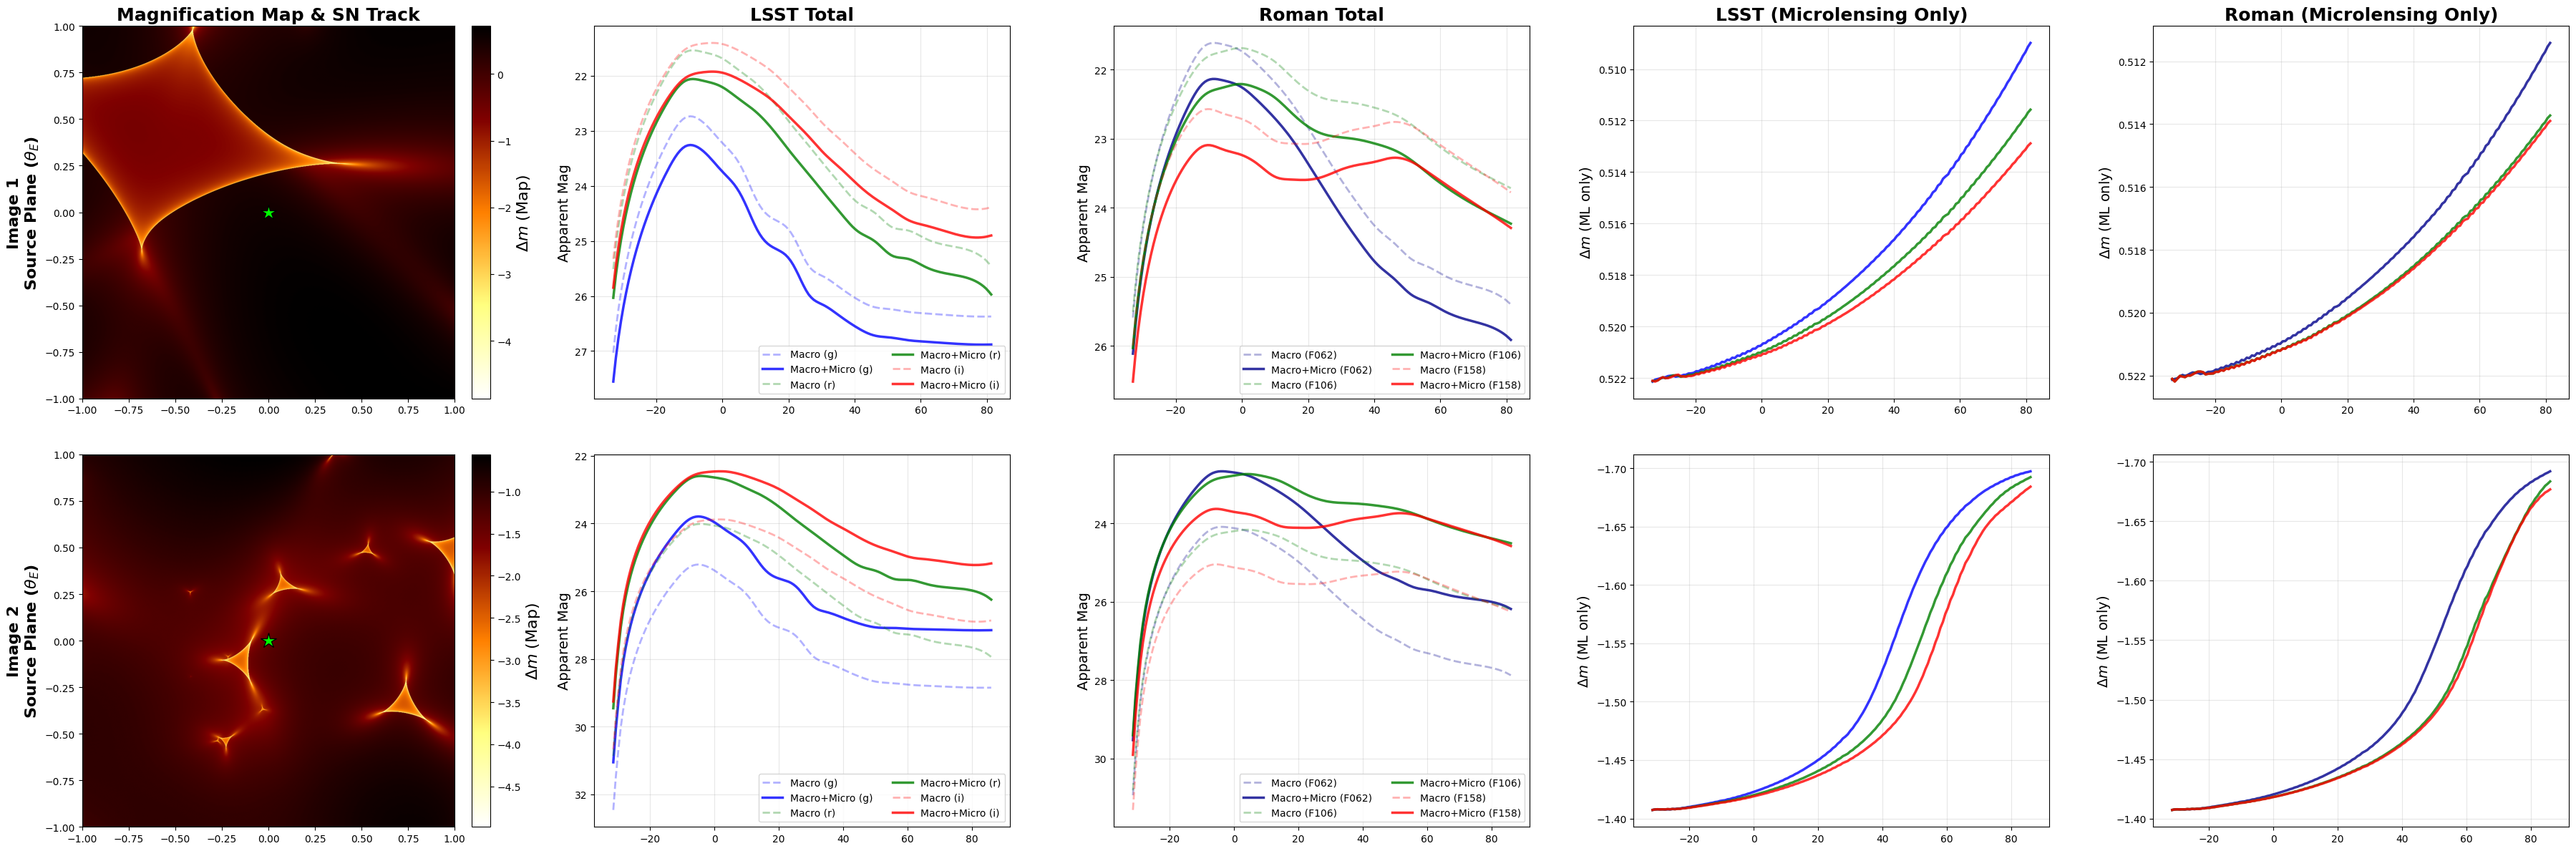

In [ ]:
compare_lsst = ["g", "r", "i"]
compare_roman = ["F062", "F106", "F158"]

arrival_times = lens_class.point_source_arrival_times()[0]
t_start, t_end = (
    np.min(arrival_times + np.max(arrival_times)) - 30,
    np.max(arrival_times + np.max(arrival_times)) + 120,
)
t_test = np.linspace(t_start, t_end, 200)

theta_E_micro_arcsec, _, _ = theta_star_physical(
    z_lens=lens_class.deflector_redshift,
    z_src=lens_class.source_redshift_list[0],
    cosmo=cosmo,
    m=1.0,
)
theta_E_micro = theta_E_micro_arcsec.value

kwargs_micro = {
    "kwargs_magnification_map": {
        "theta_star": theta_E_micro,
        "half_length_x": 1 * theta_E_micro,
        "half_length_y": 1 * theta_E_micro,
        "num_pixels_x": 1000,
        "num_pixels_y": 1000,
    },
    "kwargs_source_morphology": {"grid_pixels": 100},
}

print("Processing Multi-Band SNe Macrolensing and Microlensing...")
lsst_macro, lsst_micro, roman_macro, roman_micro = {}, {}, {}, {}

for band in compare_lsst:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    lsst_macro[band] = lens_class.point_source_magnitude(
        band=band, time=t_test, lensed=True, microlensing=False
    )[0]
    lsst_micro[band] = lens_class.point_source_magnitude(
        band=band,
        time=t_test,
        lensed=True,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )[0]

for band in compare_roman:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    roman_macro[band] = lens_class.point_source_magnitude(
        band=band, time=t_test, lensed=True, microlensing=False
    )[0]
    roman_micro[band] = lens_class.point_source_magnitude(
        band=band,
        time=t_test,
        lensed=True,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )[0]

lcm = lens_class.microlensing_model_class(source_index=0)
num_images = lens_class.image_number[0]

# %%
print("Visualizing Continuous SNe Macrolensing + Microlensing Signatures...")

fig, axes = plt.subplots(num_images, 5, figsize=(36, 6 * num_images))
if num_images == 1:
    axes = np.atleast_2d(axes)

colors = {
    "g": "blue",
    "r": "green",
    "i": "red",
    "F062": "darkblue",
    "F106": "green",
    "F158": "red",
}

for i in range(num_images):
    ax_map, ax_lsst, ax_roman, ax_lsst_ml, ax_roman_ml = axes[i]

    # -------------------------------------------------------------
    # PANEL A: Magnification Map & Track
    # -------------------------------------------------------------
    magmap = lcm.magmaps_images[i]
    track_x, track_y = lcm.tracks[i][0]
    hl_te = magmap.half_length_x / theta_E_micro
    tx_te = (track_x / magmap.num_pixels_x) * (2 * hl_te) - hl_te
    ty_te = (track_y / magmap.num_pixels_x) * (2 * hl_te) - hl_te

    im = ax_map.imshow(
        -2.5 * np.log10(magmap.magnifications / np.abs(magmap.mu_ave)),
        origin="lower",
        cmap="afmhot_r",
        extent=[-hl_te, hl_te, -hl_te, hl_te],
    )
    ax_map.plot(tx_te, ty_te, color="cyan", lw=2, linestyle="--")
    ax_map.plot(
        tx_te[0],
        ty_te[0],
        marker="*",
        color="lime",
        markersize=16,
        markeredgecolor="black",
        zorder=10,
    )
    ax_map.set_ylabel(
        f"Image {i+1}\nSource Plane ($\\theta_E$)", fontweight="bold", fontsize=16
    )
    plt.colorbar(im, ax=ax_map, fraction=0.046, pad=0.04).set_label(
        r"$\Delta m$ (Map)", fontsize=16
    )

    # -------------------------------------------------------------
    # PANELS B & D: LSST Total & Micro-Only
    # -------------------------------------------------------------
    for band in compare_lsst:
        c = colors.get(band, "black")
        ax_lsst.plot(
            t_test,
            lsst_macro[band][i],
            color=c,
            linestyle="--",
            lw=2,
            alpha=0.3,
            label=f"Macro ({band})",
        )
        ax_lsst.plot(
            t_test,
            lsst_micro[band][i],
            color=c,
            lw=2.5,
            alpha=0.8,
            label=f"Macro+Micro ({band})",
        )
        ax_lsst_ml.plot(
            t_test,
            lsst_micro[band][i] - lsst_macro[band][i],
            color=c,
            lw=2.5,
            alpha=0.8,
            label=f"ML Only ({band})",
        )

    ax_lsst.invert_yaxis()
    ax_lsst_ml.invert_yaxis()
    ax_lsst.set_ylabel("Apparent Mag", fontsize=14)
    ax_lsst_ml.set_ylabel(r"$\Delta m$ (ML only)", fontsize=14)
    ax_lsst.legend(fontsize=10, ncol=2)
    ax_lsst.grid(True, alpha=0.3)
    ax_lsst_ml.grid(True, alpha=0.3)

    # -------------------------------------------------------------
    # PANELS C & E: Roman Total & Micro-Only
    # -------------------------------------------------------------
    for band in compare_roman:
        c = colors.get(band, "black")
        ax_roman.plot(
            t_test,
            roman_macro[band][i],
            color=c,
            linestyle="--",
            lw=2,
            alpha=0.3,
            label=f"Macro ({band})",
        )
        ax_roman.plot(
            t_test,
            roman_micro[band][i],
            color=c,
            lw=2.5,
            alpha=0.8,
            label=f"Macro+Micro ({band})",
        )
        ax_roman_ml.plot(
            t_test,
            roman_micro[band][i] - roman_macro[band][i],
            color=c,
            lw=2.5,
            alpha=0.8,
            label=f"ML Only ({band})",
        )

    ax_roman.invert_yaxis()
    ax_roman_ml.invert_yaxis()
    ax_roman.set_ylabel("Apparent Mag", fontsize=14)
    ax_roman_ml.set_ylabel(r"$\Delta m$ (ML only)", fontsize=14)
    ax_roman.legend(fontsize=10, ncol=2)
    ax_roman.grid(True, alpha=0.3)
    ax_roman_ml.grid(True, alpha=0.3)

    if i == 0:
        ax_map.set_title("Magnification Map & SN Track", fontsize=18, fontweight="bold")
        ax_lsst.set_title("LSST Total", fontsize=18, fontweight="bold")
        ax_roman.set_title("Roman Total", fontsize=18, fontweight="bold")
        ax_lsst_ml.set_title("LSST (Microlensing Only)", fontsize=18, fontweight="bold")
        ax_roman_ml.set_title(
            "Roman (Microlensing Only)", fontsize=18, fontweight="bold"
        )

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.15)
plt.show()

In [ ]:
# Recompute magmaps
# lens_class.reset_microlensing_model_class(0)
# Reset track starting position
# lens_class.microlensing_model_class(0).reset_start_position(x_start_position=0.0*theta_E_micro, y_start_position=-0.5*theta_E_micro)

# after this rerun the cell above to see how the microlensing signatures change with a different track realization